### 07 - Interpretability and SHAP Analysis / Interpretabilidade e Análise com SHAP

#### Overview / Visão Geral
This notebook focuses on model interpretability in the Beverage Sales project.<br>
It uses SHAP to explain how the hybrid LightGBM model behaves and to compare its predictions against the baseline model.

Este notebook é focado em interpretabilidade de modelo no projeto Beverage Sales.  
Ele usa SHAP para explicar como o modelo híbrido LightGBM se comporta e para comparar suas previsões com o modelo baseline.

---

#### Purpose / Objetivo

The main goal is to understand **why** the hybrid model makes its predictions and whether anomaly-related features, especially `anomaly_score`, have a real contribution to the final result.
This notebook also helps validate whether the hybrid approach is not only slightly better in metrics, but also more informative in difficult cases.
<br> ------ <br>
O objetivo principal é entender **por que** o modelo híbrido faz suas previsões e se as features relacionadas a anomalias, principalmente `anomaly_score`, têm contribuição real no resultado final.
Este notebook também ajuda a validar se a abordagem híbrida não é apenas um pouco melhor nas métricas, mas também mais informativa em casos difíceis.

---

#### Position in the project pipeline / Posição no pipeline do projeto

#### ⚙️The project follows this logic:
**raw data -> data quality -> feature engineering -> anomaly detection -> baseline model -> hybrid model -> performance benchmarking**

#### ⚙️Execution order
📝01_data_loading.ipynb -> 📝02_data_quality.ipynb -> 📝03_feature_engineering.ipynb -> 📝04_anomaly_detection.ipynb -> 
📝05_BaseLine.ipynb -> 📝06_HybridModel.ipynb -> 📝07_Interpretability_SHAP_Analysis.ipynb -> 📝08_performance_benchmarking.ipynb 


Suggested execution order:

1. `01_data_loading.ipynb`
2. `02_data_quality.ipynb`
3. `03_feature_engineering.ipynb`
4. `04_anomaly_detection.ipynb`
5. `05_BaseLine.ipynb`
6. `06_HybridModel.ipynb`
7. `07_Interpretability_SHAP_Analysis.ipynb`
8. `08_performance_benchmarking.ipynb`

---

#### Main idea / Ideia principal

The notebook brings together two important views:

- **performance view**: compare baseline and hybrid predictions
- **interpretability view**: explain the hybrid model using SHAP

O notebook reúne duas visões importantes:

- **visão de desempenho**: comparar as previsões do baseline e do híbrido
- **visão de interpretabilidade**: explicar o modelo híbrido usando SHAP

---

#### Inputs / Entradas

The notebook uses the following inputs:

- 📦`beverage_sales_feature.parquet`
- 📦`anomaly_predictions.parquet`
- trained baseline model
- trained hybrid model

---

#### Main processing steps / Etapas principais do processamento

#### 1. Load data / Carregar os dados

The notebook loads the feature dataset and the anomaly dataset from parquet files.

O notebook carrega o dataset de features e o dataset de anomalias a partir de arquivos parquet.

#### 2. Prepare date columns / Preparar colunas de data

`Order_Date` is converted to datetime format in both datasets.

`Order_Date` é convertido para datetime nos dois datasets.

#### 3. Merge anomaly information / Juntar informações de anomalia

The notebook merges the feature dataset with anomaly predictions using:

- `Order_Date`
- `Product`
- `Region`

O notebook faz o merge entre o dataset de features e as predições de anomalia usando:

- `Order_Date`
- `Product`
- `Region`

This creates a dataset that contains both normal business features and anomaly-related signals.

Isso cria um dataset que contém tanto as features de negócio quanto os sinais relacionados a anomalias.

#### 4. Create train and test subsets / Criar subconjuntos de treino e teste

The split is based on time:

- **2021 and 2022** -> training-like data
- **2023** -> final test data

A divisão é baseada no tempo:

- **2021 e 2022** -> dados de treino
- **2023** -> dados finais de teste

This is consistent with a time series project because it preserves chronology.

Isso é consistente com um projeto de séries temporais porque preserva a ordem temporal.

#### 5. Define features / Definir features

The notebook prepares the feature groups used by the models, including:

- business aggregation variables
- calendar variables
- rolling-window variables
- anomaly-related variables in the hybrid version

O notebook prepara os grupos de features usados pelos modelos, incluindo:

- variáveis agregadas de negócio
- variáveis de calendário
- variáveis de janela móvel
- variáveis relacionadas a anomalias na versão híbrida

#### 6. Generate predictions / Gerar previsões

The baseline model and the hybrid model are applied to the evaluation dataset.

O modelo baseline e o modelo híbrido são aplicados ao dataset de avaliação.

The notebook creates columns such as:

- `pred_baseline`
- `pred_hybrid`

O notebook cria colunas como:

- `pred_baseline`
- `pred_hybrid`

#### 7. Compare models by anomaly flag / Comparar modelos por flag de anomalia

A `ModelsMetricsReporter` object is used to compare the two models, including grouped analysis by `anomaly_flag`.

Um objeto `ModelsMetricsReporter` é usado para comparar os dois modelos, incluindo análise agrupada por `anomaly_flag`.

This step is important because it shows whether the hybrid model is especially useful in unusual or unstable demand situations.

Essa etapa é importante porque mostra se o modelo híbrido é especialmente útil em situações incomuns ou instáveis de demanda.

#### 8. Run SHAP analysis / Executar análise com SHAP

The notebook then uses a SHAP interpreter for the hybrid LightGBM model.

Depois, o notebook usa um interpretador SHAP para o modelo híbrido LightGBM.

The main SHAP analyses are:

- Summary Plot
- Dependence Plot for `anomaly_score`
- Global feature importance
- Waterfall plots for critical cases

As principais análises com SHAP são:

- Summary Plot
- Dependence Plot para `anomaly_score`
- Importância global de features
- Waterfall plots para casos críticos

---

#### SHAP sections explained / Explicação das seções de SHAP

#### Summary Plot / Gráfico de resumo

The summary plot shows which features have the largest overall impact on the hybrid model predictions.<br>
It is useful to identify the most influential variables across the full test dataset.<br><br>

O gráfico de resumo mostra quais features têm maior impacto geral nas previsões do modelo híbrido.<br>
Ele é útil para identificar as variáveis mais influentes em todo o conjunto de teste.<br>

#### Dependence Plot for `anomaly_score` / Gráfico de dependência para `anomaly_score`

This plot helps analyze whether changes in `anomaly_score` are associated with stronger positive or negative effects in the prediction.<br>
It is especially useful to see whether there is a threshold-like behavior.<br><br>

Esse gráfico ajuda a analisar se mudanças em `anomaly_score` estão associadas a efeitos mais fortes, positivos ou negativos, na predição.<br>
Ele é especialmente útil para ver se existe um comportamento parecido com limiar.<br>

#### Global feature importance / Importância global das features

The notebook extracts feature importance values from SHAP and displays the top variables.<br>
This gives a more interpretable ranking of what drives the model globally.<br><br>

O notebook extrai valores de importância a partir do SHAP e exibe as principais variáveis.<br>
Isso fornece um ranking mais interpretável do que direciona o modelo globalmente.<br>

#### Waterfall plots for critical cases / Gráficos waterfall para casos críticos

The notebook creates waterfall plots for selected critical examples.<br>
These charts help explain, case by case, how the hybrid prediction was built from different feature contributions.<br>
The configuration limits the display to a small number of features, which makes the visualization cleaner and more useful for presentations.<br><br>

O notebook cria gráficos waterfall para exemplos críticos selecionados.<br>
Esses gráficos ajudam a explicar, caso a caso, como a predição híbrida foi construída a partir de diferentes contribuições das features.<br>
A configuração limita a exibição a um número pequeno de features, o que deixa a visualização mais limpa e mais útil para apresentações.<br>

---

#### Expected outputs / Saídas esperadas

The notebook produces:

- comparison tables between baseline and hybrid models
- grouped performance analysis by anomaly flag
- SHAP summary visualization
- SHAP dependence visualization for `anomaly_score`
- global importance table
- waterfall plots for critical predictions

---

#### Why this notebook matters / Por que este notebook é importante

From a business perspective, this notebook helps explain **why the model reacts differently in unusual sales situations**.<br>
From a technical perspective, it shows that the hybrid solution is not a black box without evidence.<br>  
It provides interpretability artifacts that support the use of anomaly-related features.<br><br>

Do ponto de vista de negócio, este notebook ajuda a explicar **por que o modelo reage de forma diferente em situações incomuns de vendas**.<br>
Do ponto de vista técnico, ele mostra que a solução híbrida não é uma caixa-preta sem evidência.<br>  
Ele fornece artefatos de interpretabilidade que sustentam o uso de features relacionadas a anomalias.<br>

For a portfolio, this is valuable because it connects:

- forecasting performance
- anomaly detection
- explainable AI

---

#### ⚙️The project follows this logic:
**raw data -> data quality -> feature engineering -> anomaly detection -> baseline model -> hybrid model -> performance benchmarking**

#### ⚙️Execution order
📝01_data_loading.ipynb -> 📝02_data_quality.ipynb -> 📝03_feature_engineering.ipynb -> 📝04_anomaly_detection.ipynb -> 
📝05_BaseLine.ipynb -> 📝06_HybridModel.ipynb -> 📝07_Interpretability_SHAP_Analysis.ipynb -> 📝08_performance_benchmarking.ipynb 

In [2]:
# =========================================================
# 1) IMPORTS
# =========================================================
%load_ext autoreload
%autoreload 2

import os
import glob
from pathlib import Path
import sys
import pyarrow
import pandas as pd
import shap
import matplotlib.pyplot as plt


PROJECT_ROOT = Path().resolve().parent
sys.path.append(str(PROJECT_ROOT))

from src.repository.parquet_repository import ParquetRepository
from src.models.LightGBMRegressorBaseLine import LightGBMRegressorBaseLine
from src.models.LightGBMRegressorAnomaly import LightGBMRegressorAnomaly
from src.visualization.ModelsMetricsReporter import ModelsMetricsReporter
from src.config.config import DATA_PROCESSED, DATA_FEATURES, MODELS_BASELINE,MODELS_METRICS

from src.XAI.LightGBMShapInterpreter import LightGBMShapInterpreter
from src.models.IsolationForest import IsolationForestAnalyzer

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [3]:
# =========================================================
# 2) EXEMPLO DE DADOS ESPERADOS
# =========================================================
# df_test_pred -> dataframe final de teste com:
# - features usadas no modelo
# - y_true (valor real)
# - pred_baseline
# - pred_hybrid
# - anomaly_score
# - anomaly_flag
#
# Ajuste os nomes abaixo se no seu projeto estiverem diferentes.

TARGET_COL = "quantity_sum"          # valor real
BASELINE_PRED_COL = "pred_baseline"  # predição baseline
HYBRID_PRED_COL = "pred_hybrid"      # predição modelo híbrido

In [4]:
repo = ParquetRepository(DATA_FEATURES)

In [5]:
df_features = repo.load("beverage_sales_feature.parquet")
df_anomalies = repo.load("anomaly_predictions.parquet")

df_features["Order_Date"] = pd.to_datetime(df_features["Order_Date"])
df_anomalies["Order_Date"] = pd.to_datetime(df_anomalies["Order_Date"])

[OK] Arquivo carregado: D:\PROJETOS\git_repo\BEVERAGE-SALES\data\features\beverage_sales_feature.parquet
[OK] Arquivo carregado: D:\PROJETOS\git_repo\BEVERAGE-SALES\data\features\anomaly_predictions.parquet


In [6]:
df_model_with_anomaly = df_features.merge(
    df_anomalies,
    on=["Order_Date", "Product", "Region"],
    how="left"
)

In [7]:
df_features["Order_Date"] = pd.to_datetime(df_features["Order_Date"])

df_train_features = df_features[df_features["Order_Date"].dt.year.isin([2021, 2022])].copy()
df_test_features = df_features[df_features["Order_Date"].dt.year == 2023].copy()

In [8]:
df_anomalies["Order_Date"] = pd.to_datetime(df_anomalies["Order_Date"])

df_train_anomaly = df_anomalies[df_anomalies["Order_Date"].dt.year.isin([2021, 2022])].copy()
df_test_anomaly = df_anomalies[df_anomalies["Order_Date"].dt.year == 2023].copy()

In [9]:
target_col = "quantity_sum"

numeric_features = [
    "total_price_sum",
    "unit_price_mean",
    "discount_mean",
    "order_count",
    "customer_count",
    "avg_ticket",
    "day_of_week",
    "month",
    "is_weekend",
    "quantity_sum_mean_7d",
    "quantity_sum_std_7d",
    "quantity_sum_sum_7d",
    "total_price_sum_mean_7d",
    "total_price_sum_std_7d",
    "total_price_sum_mean_30d",
    "unit_price_mean_mean_7d",
    "discount_mean_mean_14d",
    "quantity_vs_mean_7d",
    "total_price_vs_mean_30d",
    "quantity_pct_vs_mean_7d",
    "history_less_than_7d",
    "history_less_than_30d"
]

categorical_features = [
    "Product",
    "Region"
]

baseline_model = LightGBMRegressorBaseLine(
    target_col=target_col,
    numeric_features=numeric_features,
    categorical_features=categorical_features,
    model_dir=MODELS_BASELINE,
    random_state=3,
    n_splits=3,
    scoring="neg_root_mean_squared_error"
)

LOCAL_BASELINE = MODELS_BASELINE / "lightgbm_baseline_model.joblib"
baseline_model.load_model(LOCAL_BASELINE)

In [10]:
target_col = "quantity_sum"

numeric_features = [
    "total_price_sum",
    "unit_price_mean",
    "discount_mean",
    "order_count",
    "customer_count",
    "avg_ticket",
    "day_of_week",
    "month",
    "is_weekend",
    "quantity_sum_mean_7d",
    "quantity_sum_std_7d",
    "quantity_sum_sum_7d",
    "total_price_sum_mean_7d",
    "total_price_sum_std_7d",
    "total_price_sum_mean_30d",
    "unit_price_mean_mean_7d",
    "discount_mean_mean_14d",
    "quantity_vs_mean_7d",
    "total_price_vs_mean_30d",
    "quantity_pct_vs_mean_7d",
    "history_less_than_7d",
    "history_less_than_30d",
    "anomaly_score",
    "anomaly_flag"
]

categorical_features = [
    "Product",
    "Region"
]

hybrid_model = LightGBMRegressorAnomaly(
    target_col=target_col,
    numeric_features=numeric_features,
    categorical_features=categorical_features,
    model_dir=MODELS_BASELINE,
    random_state=3,
    n_splits=3,
    scoring="neg_root_mean_squared_error"
)

LOCAL_HYBRID_MODEL = MODELS_BASELINE / "lightgbm_anomalies_model.joblib"
hybrid_model.load_model(LOCAL_HYBRID_MODEL)

In [11]:
df_eval = df_test_anomaly.copy()

df_eval["pred_baseline"] = baseline_model.predict(df_eval)
df_eval["pred_hybrid"] = hybrid_model.predict(df_eval)

TARGET_COL = "quantity_sum"
BASELINE_PRED_COL = "pred_baseline"
HYBRID_PRED_COL = "pred_hybrid"

d:\PROJETOS\git_repo\BEVERAGE-SALES\_venv\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
d:\PROJETOS\git_repo\BEVERAGE-SALES\_venv\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


In [12]:
modelreport = ModelsMetricsReporter (df_baseline=df_train_features, df_with_anomaly=df_train_anomaly)

report, df_compare = modelreport.compare_models_by_anomaly_flag(
    baseline_model=baseline_model,
    anomaly_model=hybrid_model,
    target_col="quantity_sum",
    anomaly_flag_col="anomaly_flag",
    id_columns=["Order_Date", "Product", "Region"]
)

d:\PROJETOS\git_repo\BEVERAGE-SALES\_venv\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
d:\PROJETOS\git_repo\BEVERAGE-SALES\_venv\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


In [13]:
print(report)

   anomaly_flag   count  baseline_mae  anomaly_model_mae  baseline_median_ae  \
0             0  543470      2.690491            2.69468            1.915619   
1             1    5490      6.394622            6.22014            2.635442   

   anomaly_model_median_ae  baseline_rmse  anomaly_model_rmse  \
0                 1.913718       3.969947            3.967023   
1                 2.639001      13.011426           12.314362   

   baseline_max_ae  anomaly_model_max_ae  mae_improvement  rmse_improvement  \
0       158.320738            151.348713        -0.004188          0.002924   
1       123.955175            114.283118         0.174482          0.697065   

   mae_improvement_pct  rmse_improvement_pct  
0             -0.15566              0.073645  
1              2.72857              5.357326  


In [14]:
#shap_helper = LightGBMShapInterpreter(hybrid_model.best_model)

# gráfico summary
#shap_helper.plot_summary(
#    df_test_anomaly[hybrid_model.numeric_features + hybrid_model.categorical_features],
#    plot_type="dot"
#)

In [15]:
# =========================================================
# 3) LIGHTGBM + SHAP
# =========================================================
# pipeline_hybrid deve ser o pipeline sklearn com:
# - preprocessor
# - model
#
# Exemplo:
# shap_interpreter = LightGBMShapInterpreter(hybrid_model.best_model)

shap_interpreter = LightGBMShapInterpreter(hybrid_model.best_model)

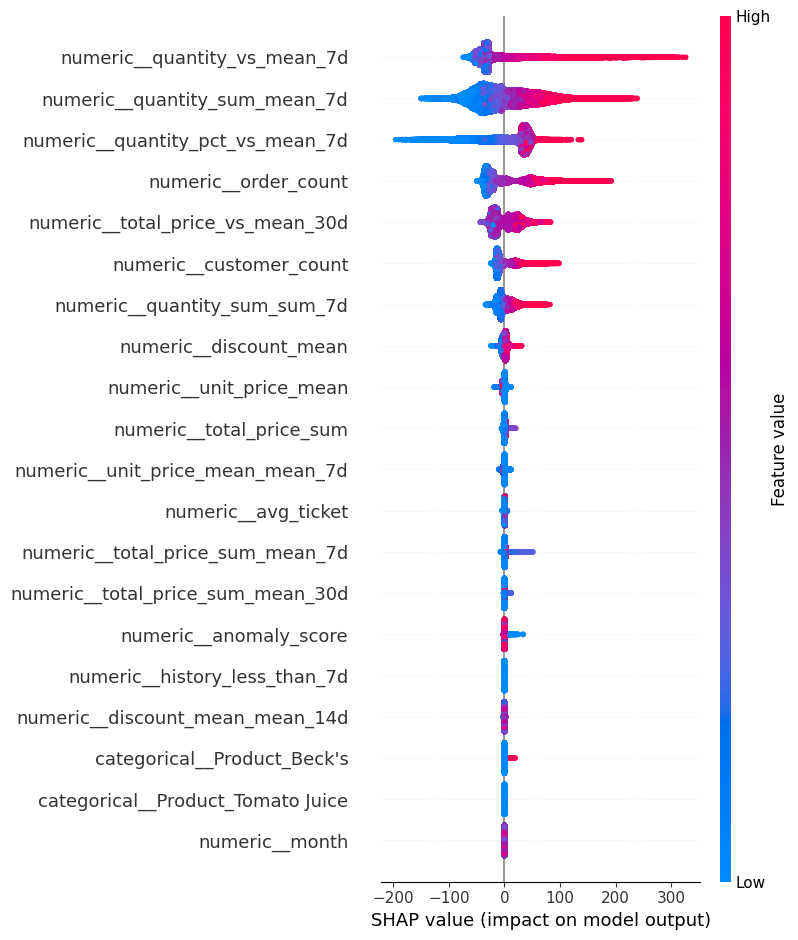

<Figure size 640x480 with 0 Axes>

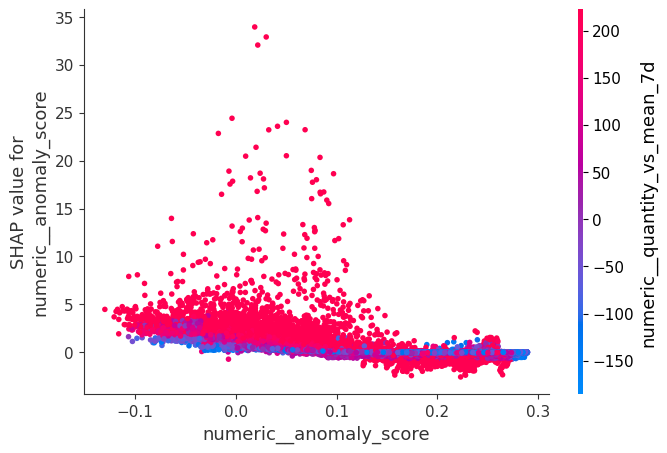

In [16]:
# ---------------------------------------------------------
# 3.1 Summary Plot
# ---------------------------------------------------------
plt.figure()
shap_interpreter.plot_summary(df_test_anomaly, plot_type="dot")

# ---------------------------------------------------------
# 3.2 Dependence Plot do anomaly_score
# ---------------------------------------------------------
# Ideal para verificar se existe "threshold" no impacto do anomaly_score
plt.figure()
shap_interpreter.plot_dependence(
    df=df_test_anomaly,
    feature_name="anomaly_score",
    interaction_index="auto"
)

In [17]:
# ---------------------------------------------------------
# 3.3 Importância global
# ---------------------------------------------------------
importance_df = shap_interpreter.get_feature_importance(df_test_anomaly)
display(importance_df.head(15))


,feature,mean_abs_shap
0,numeric__quantity_vs_mean_7d,42.559717
1,numeric__quantity_sum_mean_7d,41.385751
2,numeric__quantity_pct_vs_mean_7d,38.177039
3,numeric__order_count,34.693224
4,numeric__total_price_vs_mean_30d,18.626522
5,numeric__customer_count,15.118905
6,numeric__quantity_sum_sum_7d,10.596499
7,numeric__discount_mean,2.787903
8,numeric__unit_price_mean,1.469957
9,numeric__total_price_sum,1.296059


In [18]:
print([df_test_anomaly.columns.str.contains("anomaly", case=False, na=False)])

[array([False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False,  True,
        True,  True])]


d:\PROJETOS\git_repo\BEVERAGE-SALES\_venv\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
d:\PROJETOS\git_repo\BEVERAGE-SALES\_venv\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


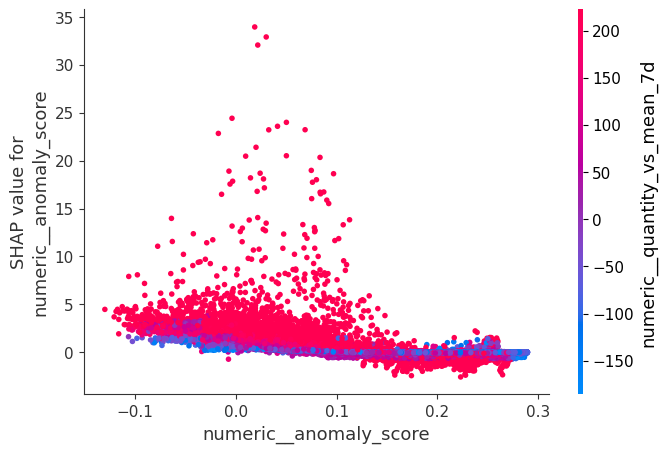

,quantity_sum,pred_baseline,pred_hybrid,baseline_abs_error,hybrid_abs_error,error_reduction
204569,867.0,781.090816,843.957993,85.909184,23.042007,62.867178
195524,1074.0,1131.467933,1084.245036,57.467933,10.245036,47.222896
592856,1020.0,970.614221,1023.422194,49.385779,3.422194,45.963585


In [19]:
# ---------------------------------------------------------
# 1) gerar predições
# ---------------------------------------------------------
df_eval = df_test_anomaly.copy()

# baseline_model: instância de LightGBMRegressorBaseLine
df_eval["pred_baseline"] = baseline_model.predict(df_eval)

# pipeline_hybrid: pipeline sklearn do modelo híbrido
df_eval["pred_hybrid"] = hybrid_model.predict(df_eval)

TARGET_COL = "quantity_sum"
BASELINE_PRED_COL = "pred_baseline"
HYBRID_PRED_COL = "pred_hybrid"

# ---------------------------------------------------------
# 2) SHAP do modelo híbrido
# ---------------------------------------------------------
shap_interpreter = LightGBMShapInterpreter(hybrid_model.best_model)

shap_interpreter.plot_dependence(
    df=df_eval,
    feature_name="anomaly_score",
    interaction_index="auto"
)

critical_cases = shap_interpreter.find_critical_corrections(
    df=df_eval,
    y_true_col=TARGET_COL,
    baseline_pred_col=BASELINE_PRED_COL,
    hybrid_pred_col=HYBRID_PRED_COL,
    top_n=3
)

display(
    critical_cases[
        [
            TARGET_COL,
            BASELINE_PRED_COL,
            HYBRID_PRED_COL,
            "baseline_abs_error",
            "hybrid_abs_error",
            "error_reduction"
        ]
    ]
)




Critical case index: 204569
Actual: 867.0000
Baseline prediction: 781.0908
Hybrid prediction: 843.9580
Error reduction: 62.8672


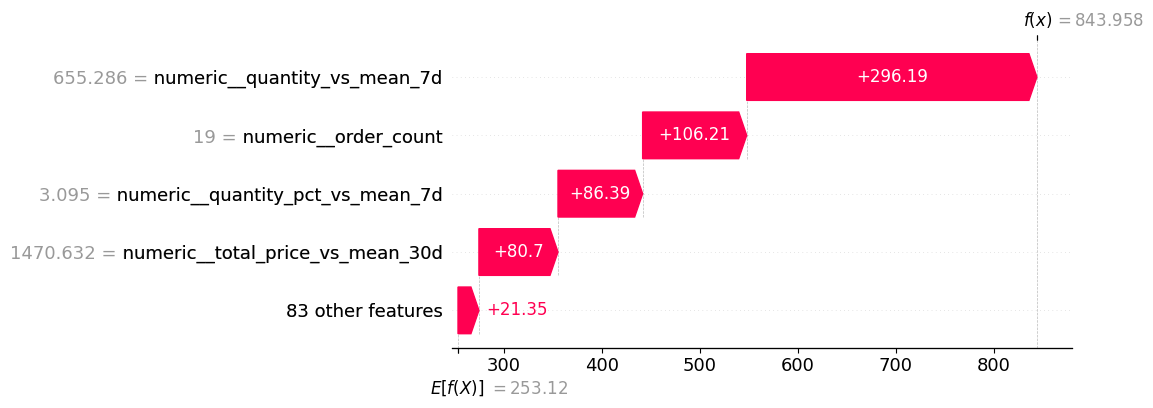


Critical case index: 195524
Actual: 1074.0000
Baseline prediction: 1131.4679
Hybrid prediction: 1084.2450
Error reduction: 47.2229


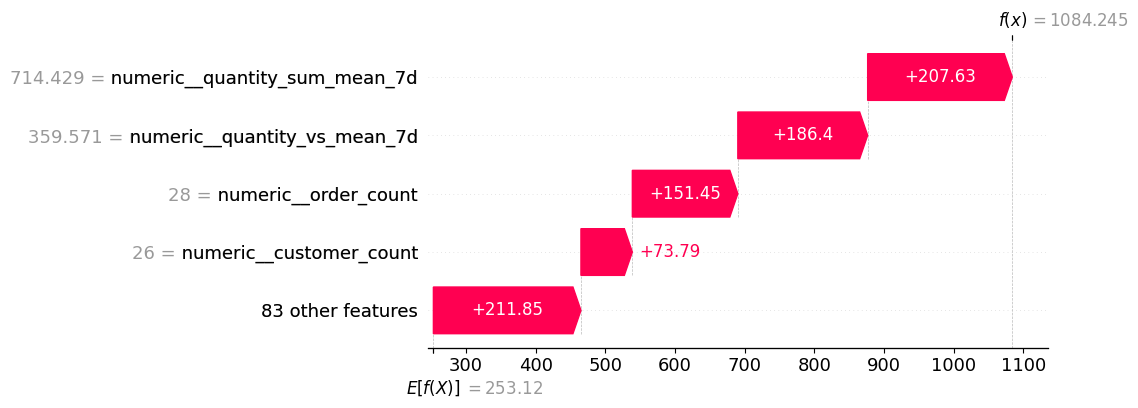


Critical case index: 592856
Actual: 1020.0000
Baseline prediction: 970.6142
Hybrid prediction: 1023.4222
Error reduction: 45.9636


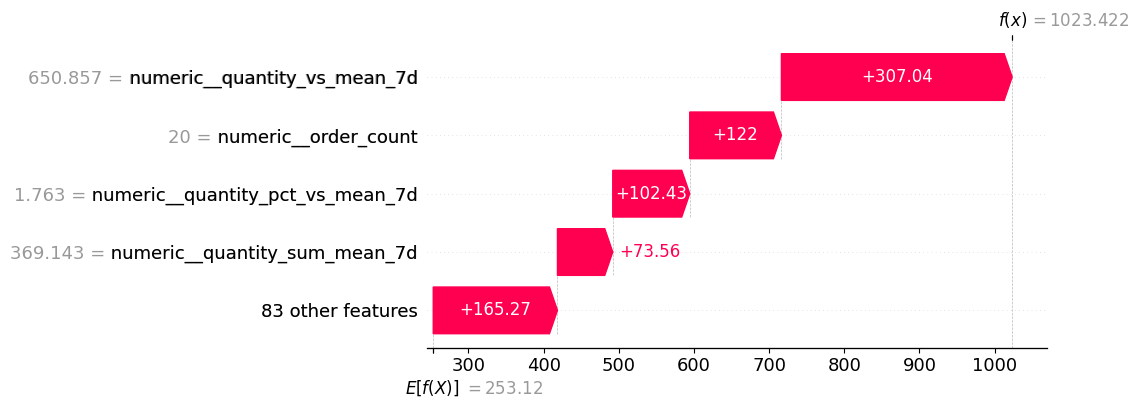

[{'row_index': 204569,
  'actual': 867.0,
  'baseline_prediction': 781.0908155003805,
  'hybrid_prediction': 843.9579934597662,
  'error_reduction': 62.867177959385685},
 {'row_index': 195524,
  'actual': 1074.0,
  'baseline_prediction': 1131.4679325129669,
  'hybrid_prediction': 1084.245036268646,
  'error_reduction': 47.222896244320964},
 {'row_index': 592856,
  'actual': 1020.0,
  'baseline_prediction': 970.6142210150084,
  'hybrid_prediction': 1023.4221944133599,
  'error_reduction': 45.96358457163171}]

In [20]:
shap_interpreter.plot_waterfall_for_critical_cases(
    X_df=df_eval,
    analysis_df=df_eval,
    y_true_col="quantity_sum",
    baseline_pred_col="pred_baseline",
    hybrid_pred_col="pred_hybrid",
    top_n=3,
    max_display=5
)